<a href="https://colab.research.google.com/github/Deepmalika/indian-startup-funding-analysis/blob/main/Indian_Startup_Funding_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()


Saving indian_startup_funding_2020_2025_sample.csv to indian_startup_funding_2020_2025_sample.csv
Saving startup_funding.csv to startup_funding.csv


In [3]:
import pandas as pd
df1 = pd.read_csv('indian_startup_funding_2020_2025_sample.csv')
df2 = pd.read_csv('startup_funding.csv')
print(df1.columns, df1.shape)
print(df2.columns, df2.shape)
df1.head()
df2.head()

Index(['Startup', 'Industry', 'SubVertical', 'City', 'Investors',
       'InvestmentType', 'InvestmentAmount_USD', 'Date'],
      dtype='object') (1100, 8)
Index(['Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical',
       'SubVertical', 'City  Location', 'Investors Name', 'InvestmentnType',
       'Amount in USD', 'Remarks'],
      dtype='object') (3044, 10)


,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


In [10]:
import pandas as pd
import numpy as np

# df1 = 2020-2025 dataset, df2 = 2015-2019 (classic) dataset

# Rename df1 columns
df1 = df1.rename(columns={
    'Startup': 'startup_name',
    'Industry': 'sector',
    'SubVertical': 'subvertical',
    'City': 'city',
    'Investors': 'investors',
    'InvestmentType': 'investment_type',
    'InvestmentAmount_USD': 'amount_usd',
    'Date': 'date'
})

# Rename df2 columns
df2 = df2.rename(columns={
    'Date dd/mm/yyyy': 'date',
    'Startup Name': 'startup_name',
    'Industry Vertical': 'sector',
    'SubVertical': 'subvertical',
    'City  Location': 'city',
    'Investors  Name': 'investors',
    'InvestmentnType': 'investment_type',
    'Amount in USD': 'amount_usd'
})




In [11]:
df2 = df2.rename(columns={
    'Investors Name': 'investors'
})

cols = ['startup_name', 'sector', 'subvertical', 'city', 'investors', 'investment_type', 'amount_usd', 'date']
df1 = df1[cols]
df2 = df2[cols]

print(df1.columns.tolist())
print(df2.columns.tolist())

['startup_name', 'sector', 'subvertical', 'city', 'investors', 'investment_type', 'amount_usd', 'date']
['startup_name', 'sector', 'subvertical', 'city', 'investors', 'investment_type', 'amount_usd', 'date']


In [12]:
def clean_amount(val):
    if pd.isna(val):
        return np.nan
    val = str(val).replace(',', '').replace('₹', '').replace('$', '').strip()
    if val.lower() in ['undisclosed', 'unknown', 'n/a', 'nan', '']:
        return np.nan
    try:
        return float(val)
    except ValueError:
        return np.nan

df1['amount_usd'] = df1['amount_usd'].apply(clean_amount)
df2['amount_usd'] = df2['amount_usd'].apply(clean_amount)

In [13]:
df1['date'] = pd.to_datetime(df1['date'], dayfirst=True, errors='coerce')
df2['date'] = pd.to_datetime(df2['date'], dayfirst=True, errors='coerce')

# Drop rows where date failed to parse
df1 = df1.dropna(subset=['date'])
df2 = df2.dropna(subset=['date'])

In [14]:
for df in [df1, df2]:
    df['sector'] = df['sector'].astype(str).str.strip().str.title()
    df['city'] = df['city'].astype(str).str.strip().str.title()

In [15]:
df1['source_period'] = 'recent_2020_2025'
df2['source_period'] = 'early_2015_2019'

combined = pd.concat([df1, df2], ignore_index=True)
combined = combined.drop_duplicates(subset=['startup_name', 'date', 'amount_usd'])
combined = combined.dropna(subset=['amount_usd'])  # drop rows with no valid funding amount
combined['year'] = combined['date'].dt.year

print(combined.shape)
combined.head()

(3159, 10)


,startup_name,sector,subvertical,city,investors,investment_type,amount_usd,date,source_period,year
0,Housejoy,Edtech,K12,Mumbai,Lightspeed India,Seed,199000.0,2023-04-19,recent_2020_2025,2023
1,Groww,Media,Streaming,Bengaluru,IFC,Seed,1668000.0,2025-01-28,recent_2020_2025,2025
2,Groww,Mobility,Ride Sharing,Hyderabad,"Nexus Venture Partners, Peak XV",Series B,38052000.0,2021-03-14,recent_2020_2025,2021
3,FarmBox,Consumer Electronics,Wearables,Gurugram,"Kalaari Capital, Y Combinator",Seed,455000.0,2023-09-11,recent_2020_2025,2023
4,Udaan,Realestate,Rental Tech,Mumbai,Bessemer Venture Partners,Seed,89000.0,2024-01-31,recent_2020_2025,2024


In [16]:
import sqlite3
conn = sqlite3.connect('startup_funding.db')
combined.to_sql('funding', conn, if_exists='replace', index=False)

3159

In [17]:
query1 = """
SELECT year, COUNT(*) as deal_count, SUM(amount_usd) as total_funding, AVG(amount_usd) as avg_deal_size
FROM funding
GROUP BY year
ORDER BY year;
"""
yearly = pd.read_sql(query1, conn)
yearly

,year,deal_count,total_funding,avg_deal_size
0,2015,642,8.597207e+09,1.339129e+07
1,2016,586,3.828089e+09,6.532574e+06
2,2017,456,1.042931e+10,2.287129e+07
3,2018,264,5.116118e+09,1.937924e+07
4,2019,104,9.686577e+09,9.314016e+07
5,2020,202,5.146872e+09,2.547957e+07
6,2021,183,6.024899e+09,3.292295e+07
7,2022,200,4.509675e+09,2.254838e+07
8,2023,213,4.001981e+09,1.878864e+07
9,2024,225,5.979808e+09,2.657692e+07


In [18]:
query2 = """
WITH sector_yearly AS (
    SELECT sector, year, AVG(amount_usd) as avg_deal_size, COUNT(*) as deal_count
    FROM funding
    GROUP BY sector, year
    HAVING COUNT(*) >= 3
)
SELECT sector, year, avg_deal_size, deal_count,
       LAG(avg_deal_size) OVER (PARTITION BY sector ORDER BY year) as prev_year_avg,
       ROUND((avg_deal_size - LAG(avg_deal_size) OVER (PARTITION BY sector ORDER BY year))
             / LAG(avg_deal_size) OVER (PARTITION BY sector ORDER BY year) * 100, 1) as pct_change
FROM sector_yearly
ORDER BY sector, year;
"""
compression = pd.read_sql(query2, conn)
compression

,sector,year,avg_deal_size,deal_count,prev_year_avg,pct_change
0,Agritech,2020,3.811062e+07,16,NaN,NaN
1,Agritech,2021,2.692936e+07,11,3.811062e+07,-29.3
2,Agritech,2022,7.453222e+06,18,2.692936e+07,-72.3
3,Agritech,2023,1.470223e+07,13,7.453222e+06,97.3
4,Agritech,2024,3.082812e+07,17,1.470223e+07,109.7
...,...,...,...,...,...,...
120,Technology,2016,5.687608e+06,120,NaN,NaN
121,Technology,2017,7.064185e+06,139,5.687608e+06,24.2
122,Technology,2018,1.117236e+07,48,7.064185e+06,58.2
123,Technology,2019,9.666667e+06,3,1.117236e+07,-13.5


In [19]:
query3 = """
SELECT
    sector,
    CASE WHEN year < 2022 THEN 'pre_winter' ELSE 'winter_onward' END as period,
    SUM(amount_usd) as total_funding
FROM funding
GROUP BY sector, period;
"""
rotation = pd.read_sql(query3, conn)
rotation_pivot = rotation.pivot(index='sector', columns='period', values='total_funding').fillna(0)
rotation_pivot['pct_change'] = ((rotation_pivot['winter_onward'] - rotation_pivot['pre_winter']) / rotation_pivot['pre_winter'] * 100).round(1)
rotation_pivot.sort_values('pct_change')

period,pre_winter,winter_onward,pct_change
sector,,,
Online Fashion Aggregator,250000.0,0.000000e+00,-100.0
Online Counselling And Psychological Support Platform,400000.0,0.000000e+00,-100.0
Online Coupon & Comparison Platform,500000.0,0.000000e+00,-100.0
Online Diagnostic Tests Marketplace,156000.0,0.000000e+00,-100.0
Online Ed-Tech Platform,1000000.0,0.000000e+00,-100.0
...,...,...,...
Realestate,423722000.0,8.437100e+08,99.1
Logistics,524453000.0,1.090441e+09,107.9
Edtech,569497425.0,1.215676e+09,113.5


In [20]:
query4 = """
SELECT year,
       COUNT(*) as deal_count,
       AVG(amount_usd) as avg_deal_size,
       SUM(amount_usd) as total_funding
FROM funding
GROUP BY year
ORDER BY year;
"""
divergence = pd.read_sql(query4, conn)
divergence

,year,deal_count,avg_deal_size,total_funding
0,2015,642,1.339129e+07,8.597207e+09
1,2016,586,6.532574e+06,3.828089e+09
2,2017,456,2.287129e+07,1.042931e+10
3,2018,264,1.937924e+07,5.116118e+09
4,2019,104,9.314016e+07,9.686577e+09
5,2020,202,2.547957e+07,5.146872e+09
6,2021,183,3.292295e+07,6.024899e+09
7,2022,200,2.254838e+07,4.509675e+09
8,2023,213,1.878864e+07,4.001981e+09
9,2024,225,2.657692e+07,5.979808e+09


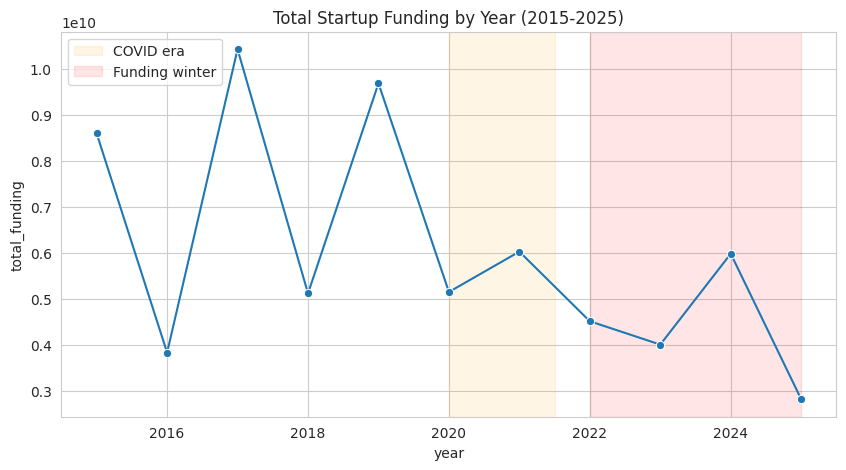

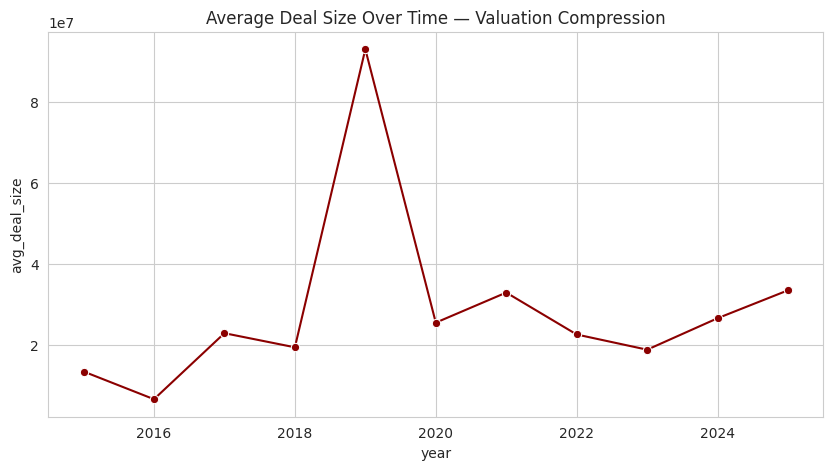

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Chart 1: Yearly funding trend
fig, ax = plt.subplots(figsize=(10,5))
sns.lineplot(data=yearly, x='year', y='total_funding', marker='o', ax=ax)
ax.axvspan(2020, 2021.5, alpha=0.1, color='orange', label='COVID era')
ax.axvspan(2022, yearly['year'].max(), alpha=0.1, color='red', label='Funding winter')
ax.set_title('Total Startup Funding by Year (2015-2025)')
ax.legend()
plt.savefig('yearly_funding_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 2: Avg deal size trend (the compression chart)
fig, ax = plt.subplots(figsize=(10,5))
sns.lineplot(data=divergence, x='year', y='avg_deal_size', marker='o', color='darkred', ax=ax)
ax.set_title('Average Deal Size Over Time — Valuation Compression')
plt.savefig('valuation_compression.png', dpi=150, bbox_inches='tight')
plt.show()



In [23]:
# Check how many unique sectors you actually have
print(combined['sector'].nunique())
print(combined['sector'].value_counts().head(20))

576
sector
Consumer Internet       589
Technology              310
Ecommerce               170
Nan                     129
E-Commerce              124
Retail                   90
Consumer Electronics     87
Media                    86
Mobility                 86
Fintech                  83
Edtech                   83
Agritech                 82
Logistics                80
Foodtech                 80
Realestate               79
Healthtech               76
Saas                     76
Enterprise               66
Finance                  57
Healthcare               45
Name: count, dtype: int64


In [24]:
combined = combined[combined['sector'] != 'Nan']
combined = combined.dropna(subset=['sector'])
print(combined['sector'].nunique())

575


In [25]:
sector_cleanup = {
    'E-Commerce': 'Ecommerce',
    'Ecommerce': 'Ecommerce',
    'Consumer Internet': 'Consumer Internet',
    'Fintech': 'Fintech',
    'Edtech': 'Edtech',
    'Ed-Tech': 'Edtech',
    'Healthtech': 'Healthtech',
    'Health-Tech': 'Healthtech',
    'Foodtech': 'Foodtech',
    'Food-Tech': 'Foodtech',
    'Agritech': 'Agritech',
    'Agri-Tech': 'Agritech',
    'Realestate': 'Real Estate',
    'Real Estate': 'Real Estate',
    'Saas': 'SaaS',
    'SAAS': 'SaaS',
    'Logistics': 'Logistics',
    'Mobility': 'Mobility',
    'Media': 'Media',
    'Retail': 'Retail',
    'Finance': 'Finance',
    'Healthcare': 'Healthcare',
    'Enterprise': 'Enterprise',
    'Consumer Electronics': 'Consumer Electronics',
    'Technology': 'Technology'
}

combined['sector_clean'] = combined['sector'].replace(sector_cleanup)
print(combined['sector_clean'].nunique())
print(combined['sector_clean'].value_counts().head(25))

571
sector_clean
Consumer Internet       589
Technology              310
Ecommerce               294
Edtech                   96
Retail                   90
Consumer Electronics     87
Media                    86
Mobility                 86
Fintech                  83
Real Estate              82
Agritech                 82
Foodtech                 81
Logistics                80
SaaS                     76
Healthtech               76
Enterprise               66
Finance                  57
Healthcare               45
Education                19
Food & Beverage          15
It                        8
Health And Wellness       6
Fin-Tech                  6
Online Food Delivery      5
Food And Beverage         5
Name: count, dtype: int64


In [26]:
top_n = 20
top_sectors = combined['sector_clean'].value_counts().head(top_n).index
combined['sector_clean'] = combined['sector_clean'].apply(lambda x: x if x in top_sectors else 'Other')

print(combined['sector_clean'].value_counts())

sector_clean
Other                   630
Consumer Internet       589
Technology              310
Ecommerce               294
Edtech                   96
Retail                   90
Consumer Electronics     87
Media                    86
Mobility                 86
Fintech                  83
Real Estate              82
Agritech                 82
Foodtech                 81
Logistics                80
SaaS                     76
Healthtech               76
Enterprise               66
Finance                  57
Healthcare               45
Education                19
Food & Beverage          15
Name: count, dtype: int64


In [27]:
combined.to_sql('funding', conn, if_exists='replace', index=False)

3030

In [28]:
query1 = """
SELECT year, COUNT(*) as deal_count, SUM(amount_usd) as total_funding, AVG(amount_usd) as avg_deal_size
FROM funding
GROUP BY year
ORDER BY year;
"""
yearly = pd.read_sql(query1, conn)
yearly

,year,deal_count,total_funding,avg_deal_size
0,2015,513,7.366246e+09,1.435915e+07
1,2016,586,3.828089e+09,6.532574e+06
2,2017,456,1.042931e+10,2.287129e+07
3,2018,264,5.116118e+09,1.937924e+07
4,2019,104,9.686577e+09,9.314016e+07
5,2020,202,5.146872e+09,2.547957e+07
6,2021,183,6.024899e+09,3.292295e+07
7,2022,200,4.509675e+09,2.254838e+07
8,2023,213,4.001981e+09,1.878864e+07
9,2024,225,5.979808e+09,2.657692e+07


In [29]:
query2 = """
WITH sector_yearly AS (
    SELECT sector_clean, year, AVG(amount_usd) as avg_deal_size, COUNT(*) as deal_count
    FROM funding
    WHERE sector_clean != 'Other'
    GROUP BY sector_clean, year
    HAVING COUNT(*) >= 3
)
SELECT sector_clean, year, avg_deal_size, deal_count,
       LAG(avg_deal_size) OVER (PARTITION BY sector_clean ORDER BY year) as prev_year_avg,
       ROUND((avg_deal_size - LAG(avg_deal_size) OVER (PARTITION BY sector_clean ORDER BY year))
             / LAG(avg_deal_size) OVER (PARTITION BY sector_clean ORDER BY year) * 100, 1) as pct_change
FROM sector_yearly
ORDER BY sector_clean, year;
"""
compression = pd.read_sql(query2, conn)
compression

,sector_clean,year,avg_deal_size,deal_count,prev_year_avg,pct_change
0,Agritech,2020,3.811062e+07,16,NaN,NaN
1,Agritech,2021,2.692936e+07,11,3.811062e+07,-29.3
2,Agritech,2022,7.453222e+06,18,2.692936e+07,-72.3
3,Agritech,2023,1.470223e+07,13,7.453222e+06,97.3
4,Agritech,2024,3.082812e+07,17,1.470223e+07,109.7
...,...,...,...,...,...,...
106,SaaS,2025,4.222522e+07,9,4.439025e+07,-4.9
107,Technology,2016,5.687608e+06,120,NaN,NaN
108,Technology,2017,7.064185e+06,139,5.687608e+06,24.2
109,Technology,2018,1.117236e+07,48,7.064185e+06,58.2


In [30]:
query3 = """
SELECT
    sector_clean,
    CASE WHEN year < 2022 THEN 'pre_winter' ELSE 'winter_onward' END as period,
    SUM(amount_usd) as total_funding
FROM funding
WHERE sector_clean != 'Other'
GROUP BY sector_clean, period;
"""
rotation = pd.read_sql(query3, conn)
rotation_pivot = rotation.pivot(index='sector_clean', columns='period', values='total_funding').fillna(0)

# Only keep sectors present in both periods (avoids infinite/meaningless % for sectors with 0 in one period)
rotation_pivot = rotation_pivot[(rotation_pivot['pre_winter'] > 0) & (rotation_pivot['winter_onward'] > 0)]
rotation_pivot['pct_change'] = ((rotation_pivot['winter_onward'] - rotation_pivot['pre_winter']) / rotation_pivot['pre_winter'] * 100).round(1)
rotation_pivot.sort_values('pct_change')

period,pre_winter,winter_onward,pct_change
sector_clean,,,
Ecommerce,9.382106e+09,6.368320e+08,-93.2
Fintech,1.981550e+09,8.740360e+08,-55.9
Healthtech,1.076061e+09,5.474560e+08,-49.1
Media,1.245465e+09,1.047519e+09,-15.9
Enterprise,6.811630e+08,7.328690e+08,7.6
Agritech,9.059930e+08,1.236566e+09,36.5
Retail,9.878010e+08,1.686873e+09,70.8
Foodtech,1.233419e+09,2.244263e+09,82.0
Real Estate,4.532220e+08,8.437100e+08,86.2


In [31]:
query4 = """
SELECT year,
       COUNT(*) as deal_count,
       AVG(amount_usd) as avg_deal_size,
       SUM(amount_usd) as total_funding
FROM funding
GROUP BY year
ORDER BY year;
"""
divergence = pd.read_sql(query4, conn)
divergence

,year,deal_count,avg_deal_size,total_funding
0,2015,513,1.435915e+07,7.366246e+09
1,2016,586,6.532574e+06,3.828089e+09
2,2017,456,2.287129e+07,1.042931e+10
3,2018,264,1.937924e+07,5.116118e+09
4,2019,104,9.314016e+07,9.686577e+09
5,2020,202,2.547957e+07,5.146872e+09
6,2021,183,3.292295e+07,6.024899e+09
7,2022,200,2.254838e+07,4.509675e+09
8,2023,213,1.878864e+07,4.001981e+09
9,2024,225,2.657692e+07,5.979808e+09


In [32]:
query5 = """
SELECT sector_clean, SUM(amount_usd) as total_funding, COUNT(*) as deal_count
FROM funding
WHERE sector_clean != 'Other'
GROUP BY sector_clean
ORDER BY total_funding DESC;
"""
top_sectors_overall = pd.read_sql(query5, conn)
top_sectors_overall

,sector_clean,total_funding,deal_count
0,Ecommerce,1.001894e+10,294
1,Consumer Internet,6.247834e+09,589
2,Foodtech,3.477682e+09,81
3,Fintech,2.855586e+09,83
4,Consumer Electronics,2.703489e+09,87
5,Retail,2.674674e+09,90
6,Mobility,2.460096e+09,86
7,Media,2.292984e+09,86
8,Technology,2.229708e+09,310
9,Agritech,2.142559e+09,82


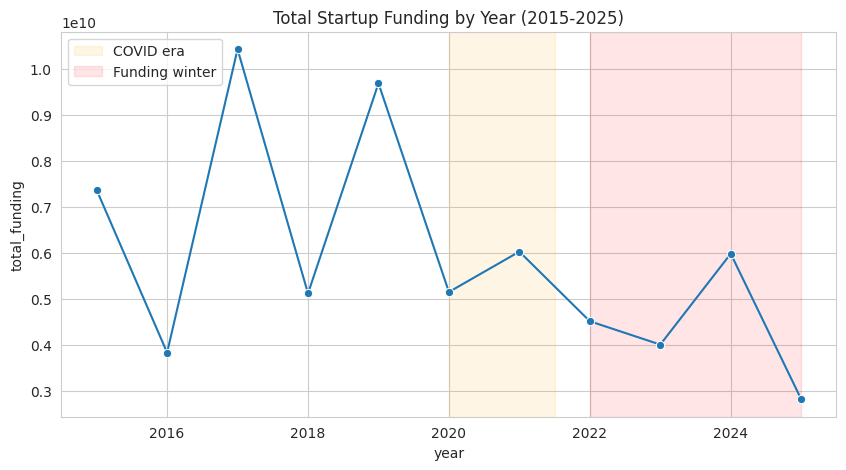

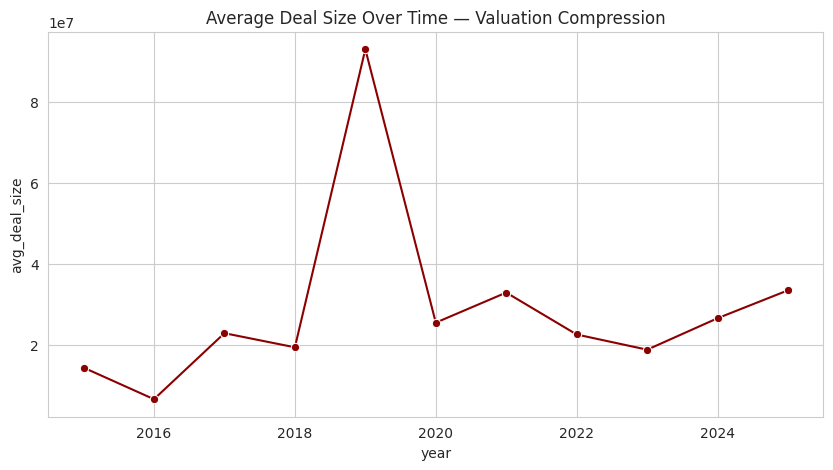

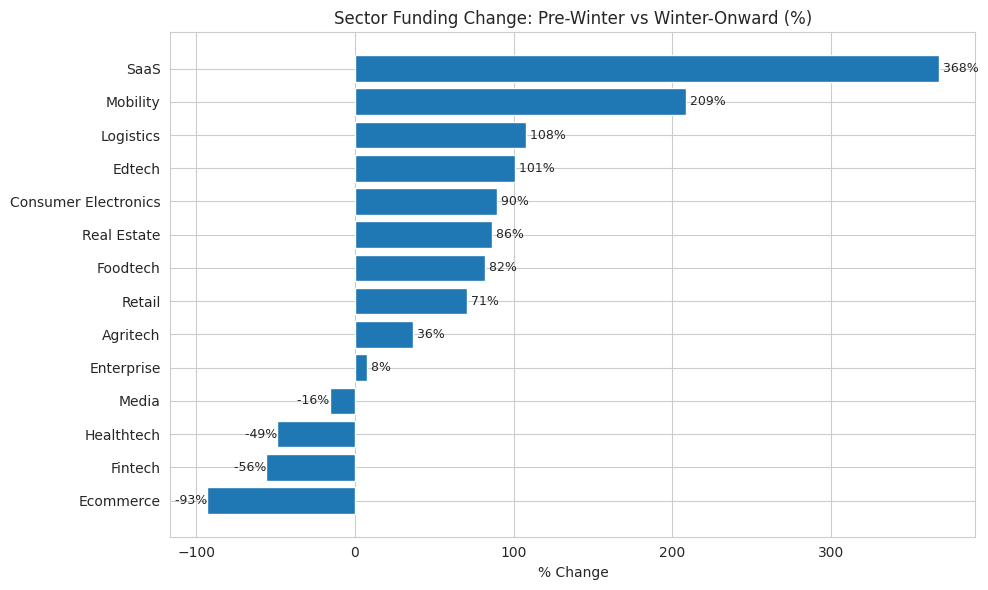

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

# Chart 1: Yearly funding trend
fig, ax = plt.subplots(figsize=(10,5))
sns.lineplot(data=yearly, x='year', y='total_funding', marker='o', ax=ax)
ax.axvspan(2020, 2021.5, alpha=0.1, color='orange', label='COVID era')
ax.axvspan(2022, yearly['year'].max(), alpha=0.1, color='red', label='Funding winter')
ax.set_title('Total Startup Funding by Year (2015-2025)')
ax.legend()
plt.savefig('yearly_funding_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 2: Avg deal size trend (the compression chart)
fig, ax = plt.subplots(figsize=(10,5))
sns.lineplot(data=divergence, x='year', y='avg_deal_size', marker='o', color='darkred', ax=ax)
ax.set_title('Average Deal Size Over Time — Valuation Compression')
plt.savefig('valuation_compression.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 3: Sector rotation
fig, ax = plt.subplots(figsize=(10,6))
sorted_data = rotation_pivot.sort_values('pct_change')['pct_change']
bars = ax.barh(sorted_data.index, sorted_data.values)
ax.set_title('Sector Funding Change: Pre-Winter vs Winter-Onward (%)')
ax.set_xlabel('% Change')

# Add value labels at the end of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2,
             f' {width:.0f}%',
             va='center', ha='left' if width >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.savefig('sector_rotation.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
combined[combined['year'] == 2019].sort_values('amount_usd', ascending=False).head(10)

,startup_name,sector,subvertical,city,investors,investment_type,amount_usd,date,source_period,year,sector_clean
1160,Rapido Bike Taxi,Transportation,Bike Taxi,Bengaluru,Westbridge Capital,Series B,3.900000e+09,2019-08-27,early_2015_2019,2019,Other
1131,Paytm,Fintech,Mobile Wallet,Noida,Vijay Shekhar Sharma,Funding Round,1.000000e+09,2019-11-25,early_2015_2019,2019,Fintech
1133,Udaan,B2B,Business development,Bengaluru,"Altimeter Capital, DST Global",Series D,5.850000e+08,2019-10-02,early_2015_2019,2019,Other
1142,GOQii,Health And Wellness,Wearable Fitness Bands,Menlo Park,Bennett Coleman and Company Ltd (BCCL),Series C,4.500000e+08,2019-09-04,early_2015_2019,2019,Other
1129,Vogo Automotive,Last Mile Transportation,Scooter sharing app,Kormangala,"Matrix Partners, Stellaris Venture Partners, K...",Series B,2.830000e+08,2019-11-15,early_2015_2019,2019,Other
1116,Lenskart.com,E-Commerce,Online Eyewear Shopping Portal,Faridabad,SoftBank Vision Fund,Series G,2.310000e+08,2019-12-20,early_2015_2019,2019,Ecommerce
1213,Zilingo,Ecommerce,Fashion & Apparel,India/Singapore,"Sequoia Capital and Temasek Holdings, EDBI, Bu...",Series D,2.260000e+08,2019-02-08,early_2015_2019,2019,Ecommerce
1127,Digital Mall Asia,E-Commerce,Virtual e-commerce platform,Delhi,Amour Infrastructure,Seed Funding,2.200000e+08,2019-11-19,early_2015_2019,2019,Ecommerce
1130,Furtados School of Music,Education,Music Education,Tulangan,IAN Fund and DSG Consumer Partners,NaN,2.000000e+08,2019-11-19,early_2015_2019,2019,Education
1192,BlackBuck,Transport,Logistics,Bengaluru,Goldman Sachs Investment Partners and Silicon ...,Series D,1.500000e+08,2019-05-01,early_2015_2019,2019,Other


In [36]:
query_median = """
SELECT year, AVG(amount_usd) as avg_deal_size,
       -- SQLite has no native MEDIAN, so approximate via percentile in pandas instead
       COUNT(*) as deal_count
FROM funding
GROUP BY year
ORDER BY year;
"""
# Better to compute median in pandas directly:
median_by_year = combined.groupby('year')['amount_usd'].median().reset_index()
median_by_year.columns = ['year', 'median_deal_size']
median_by_year

,year,median_deal_size
0,2015,1500000.0
1,2016,1000000.0
2,2017,2250000.0
3,2018,3900000.0
4,2019,12000000.0
5,2020,1133500.0
6,2021,1040000.0
7,2022,1154500.0
8,2023,1034000.0
9,2024,1104000.0


In [37]:
combined[combined['sector_clean'] == 'Ecommerce'].groupby('year')['amount_usd'].agg(['sum','count'])

,sum,count
year,,
2015,1.008000e+07,2
2016,9.750466e+08,104
2017,5.937804e+09,71
2018,1.518401e+08,9
2019,1.153264e+09,17
2020,3.093309e+08,15
2021,8.447400e+08,23
2022,1.417200e+07,13
2023,1.442410e+08,13


In [38]:
combined[combined['startup_name'] == 'Rapido Bike Taxi']

,startup_name,sector,subvertical,city,investors,investment_type,amount_usd,date,source_period,year,sector_clean
1160,Rapido Bike Taxi,Transportation,Bike Taxi,Bengaluru,Westbridge Capital,Series B,3.900000e+09,2019-08-27,early_2015_2019,2019,Other


In [39]:
combined = combined[~((combined['startup_name'] == 'Rapido Bike Taxi') & (combined['amount_usd'] > 1e9))]

In [40]:
combined[combined['startup_name'] == 'Rapido Bike Taxi']

,startup_name,sector,subvertical,city,investors,investment_type,amount_usd,date,source_period,year,sector_clean


In [41]:
combined.to_sql('funding', conn, if_exists='replace', index=False)

# Re-run Query 1 and Query 4
query1 = """
SELECT year, COUNT(*) as deal_count, SUM(amount_usd) as total_funding, AVG(amount_usd) as avg_deal_size
FROM funding
GROUP BY year
ORDER BY year;
"""
yearly = pd.read_sql(query1, conn)

query4 = """
SELECT year, COUNT(*) as deal_count, AVG(amount_usd) as avg_deal_size, SUM(amount_usd) as total_funding
FROM funding
GROUP BY year
ORDER BY year;
"""
divergence = pd.read_sql(query4, conn)

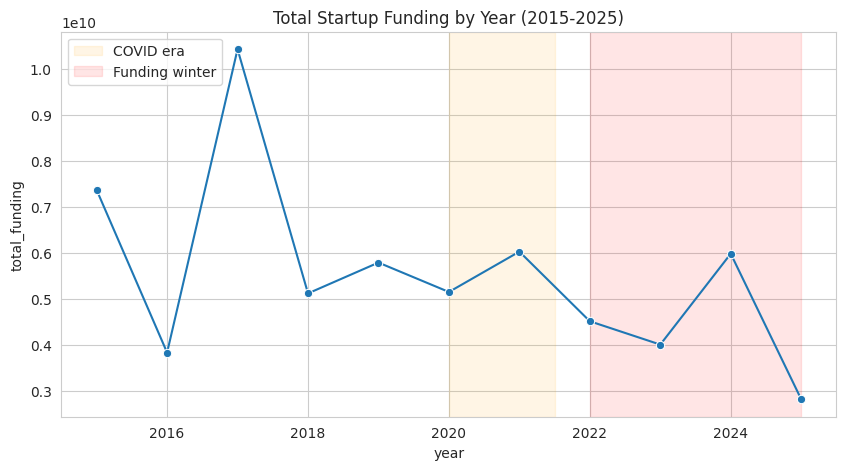

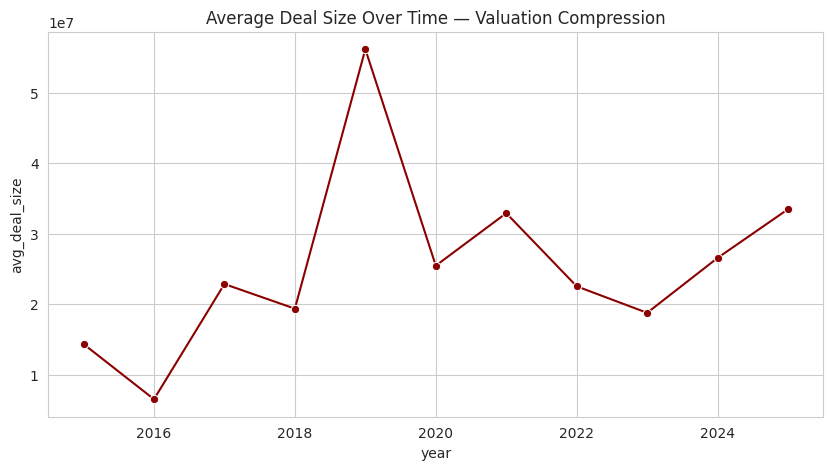

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# Chart 1: Yearly funding trend
fig, ax = plt.subplots(figsize=(10,5))
sns.lineplot(data=yearly, x='year', y='total_funding', marker='o', ax=ax)
ax.axvspan(2020, 2021.5, alpha=0.1, color='orange', label='COVID era')
ax.axvspan(2022, yearly['year'].max(), alpha=0.1, color='red', label='Funding winter')
ax.set_title('Total Startup Funding by Year (2015-2025)')
ax.legend()
plt.savefig('yearly_funding_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 2: Avg deal size trend (the compression chart)
fig, ax = plt.subplots(figsize=(10,5))
sns.lineplot(data=divergence, x='year', y='avg_deal_size', marker='o', color='darkred', ax=ax)
ax.set_title('Average Deal Size Over Time — Valuation Compression')
plt.savefig('valuation_compression.png', dpi=150, bbox_inches='tight')
plt.show()